In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.tsa.stattools import adfuller
from matplotlib.pylab import rcParams
import pmdarima as pm
from statsmodels.tsa.seasonal import seasonal_decompose


In [4]:
df=pd.read_csv('AirPassengers.csv',parse_dates=['Month'],index_col='Month')

In [5]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [10]:
df['#Passengers_diff']=df['#Passengers'].diff(periods=12).fillna(method='backfill')

C:\Users\91637\AppData\Local\Temp\ipykernel_34564\3011046682.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['#Passengers_diff']=df['#Passengers'].diff(periods=12).fillna(method='backfill')


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   #Passengers       144 non-null    int64  
 1   #Passengers_diff  144 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.4 KB


In [12]:
df.head()

,#Passengers,#Passengers_diff
Month,,
1949-01-01,112,3.0
1949-02-01,118,3.0
1949-03-01,132,3.0
1949-04-01,129,3.0
1949-05-01,121,3.0


In [13]:
result=seasonal_decompose(df['#Passengers'],model='multiplicative',period=12)
trend=result.trend.dropna()
seasonal=result.seasonal.dropna()
residual=result.resid.dropna()

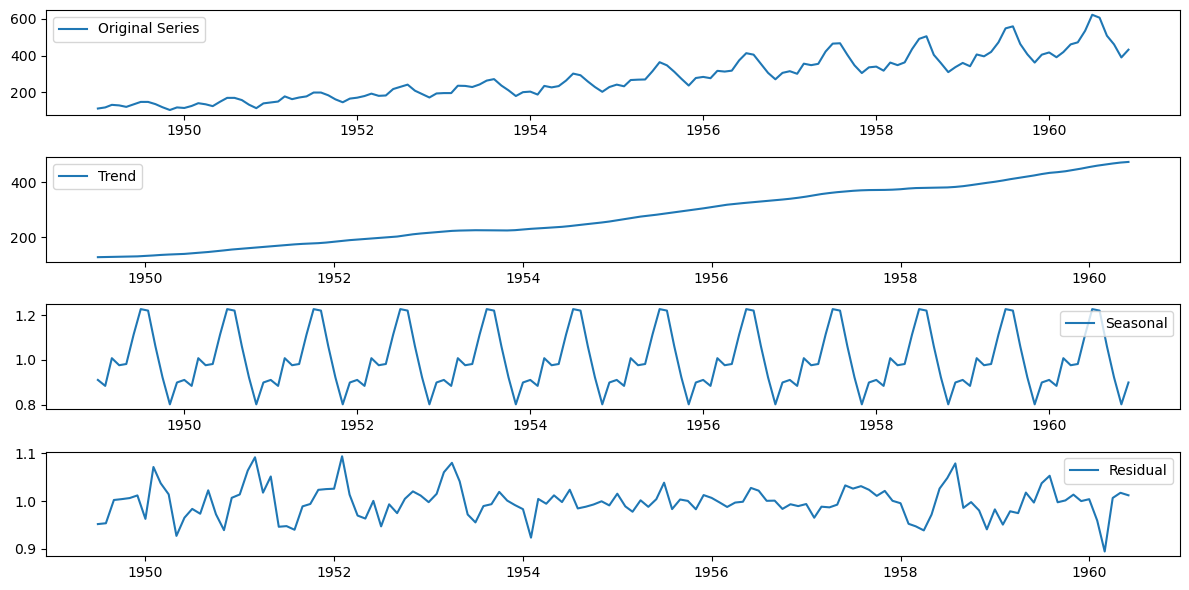

In [14]:
plt.figure(figsize=(12,6))

plt.subplot(4,1,1)
plt.plot(df['#Passengers'],label='Original Series')
plt.legend()

plt.subplot(4,1,2)
plt.plot(trend,label='Trend')
plt.legend()

plt.subplot(4,1,3)
plt.plot(seasonal,label='Seasonal')
plt.legend()

plt.subplot(4,1,4)
plt.plot(residual,label='Residual')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Exogenous variable month_index

In [16]:
df['month_index']=df.index.month

In [17]:
SARIMAX_model=pm.auto_arima(df[['#Passengers']],exogenous_df=[['month_index']],
                           start_p=1,start_q=1,test='adf',
                           max_p=3,max_q=3,
                           m=12,
                           start_P=0,seasonal=True,
                           d=None,D=1,
                           trace=False,
                           error_action='ignore',
                           suppress_warning=True,
                           stepwise=True)

  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(


In [45]:
from pandas.tseries.offsets import DateOffset

In [48]:
def sarimax_forecast(SARIMAX_model,periods=24):
    n_periods=periods

    forecast_df=pd.DataFrame({'month_index':pd.date_range(df.index[-1],periods=n_periods,freq='MS').month},
                           index=pd.date_range(df.index[-1]+DateOffset(months=1),periods=n_periods,freq='MS'))
    fitted, confint = SARIMAX_model.predict(n_periods=n_periods,
                                            return_conf_int=True,
                                            exogenous=forecast_df[['month_index']])
    index_of_fc = pd.date_range(df.index[-1] + DateOffset(months=1),
                                periods=n_periods,freq='MS')

    fitted_series = pd.Series(fitted, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)

    plt.figure(figsize=(15, 7))
    plt.plot(df['#Passengers'], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index,
                     lower_series,
                     upper_series,
                     color='k', alpha=.15)

    plt.title('SARIMAX - Forecast of Airline Passengers')
    plt.show()



  warnings.warn(
  warnings.warn(


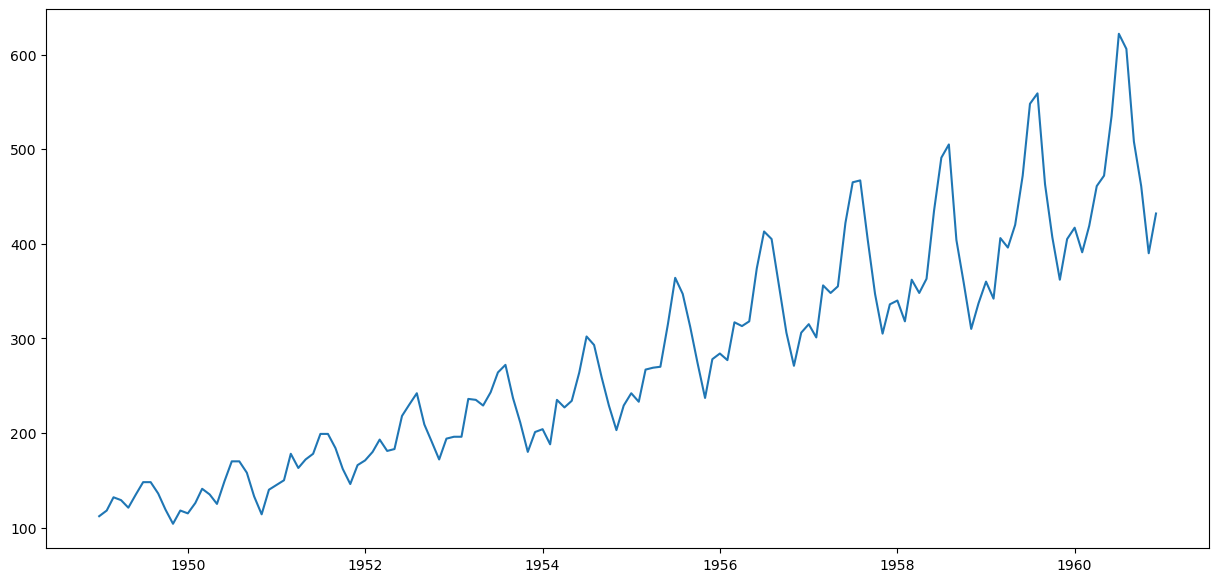

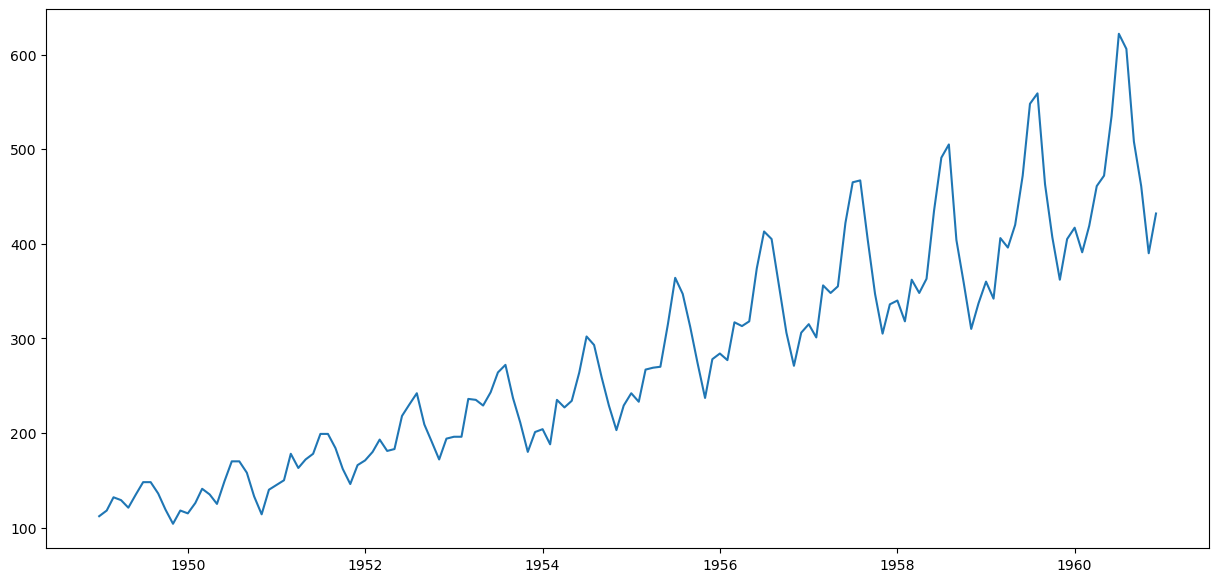

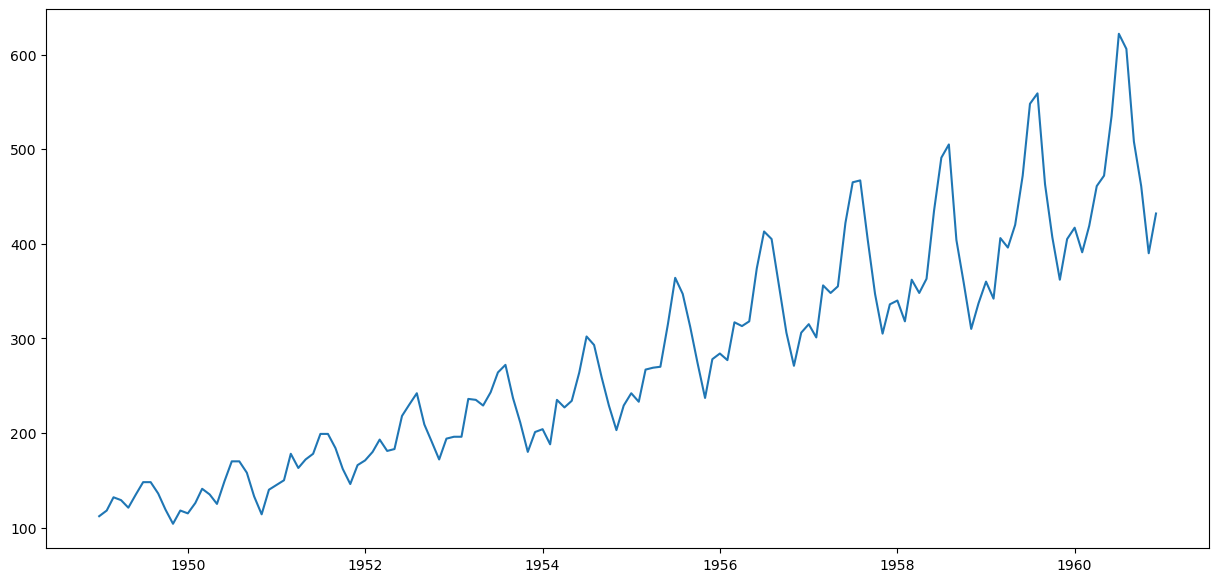

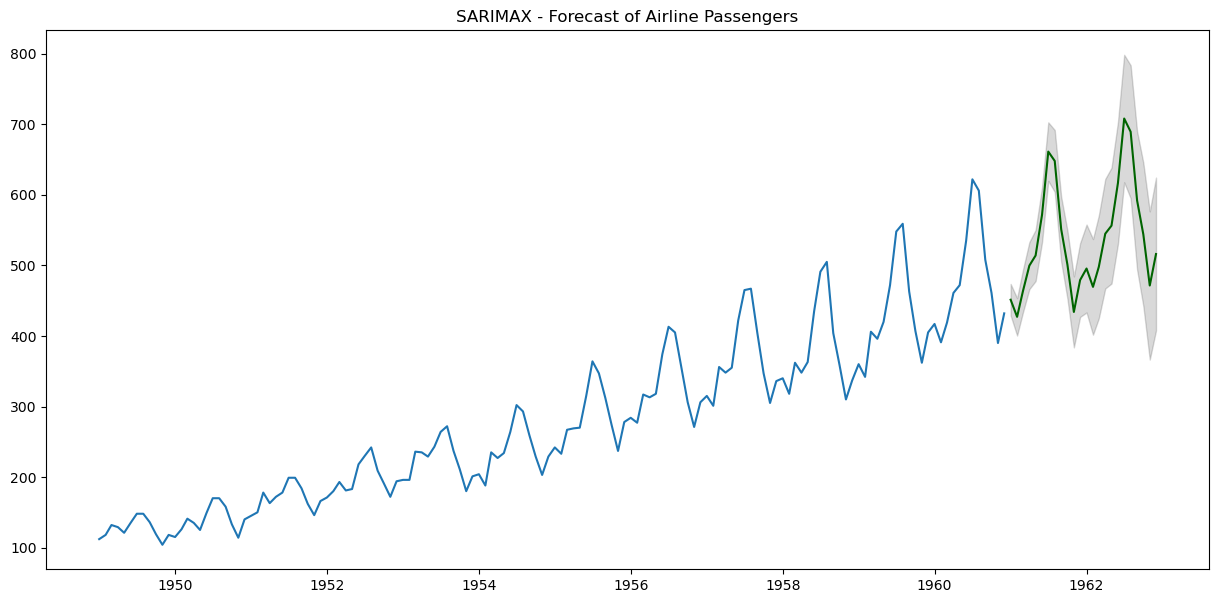

In [49]:
sarimax_forecast(SARIMAX_model, periods=24)